In [40]:
!pip install numpy pandas pymysql python-dotenv scikit-learn matplotlib shap

In [41]:
import numpy as np
import pandas as pd
import pymysql
import os
import matplotlib.pyplot as plt
from dotenv import load_dotenv
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
import sys
import db_helpers as dbh
from sklearn.ensemble import IsolationForest
import shap
import joblib

In [42]:
load_dotenv("../.env")
sys.path.append("..")

DB_NAME = os.getenv('DB_NAME')
DB_USER = os.getenv('DB_USER')
DB_PASSWORD = os.getenv('DB_PASSWORD')
DB_HOST = os.getenv('DB_HOST')
DB_PORT = int(os.getenv('DB_PORT'))
RANDOM_SEED = int(os.getenv('RANDOM_SEED', 42))

conn = pymysql.connect(
    host=DB_HOST,
    user=DB_USER,
    password=DB_PASSWORD,
    database=DB_NAME,
    port=DB_PORT,
    charset='utf8mb4'
)

city_df = dbh.get_city_hourly_consumption(conn)
city_df['timestamp'] = pd.to_datetime(city_df['timestamp'])
city_df = city_df.sort_values('timestamp').reset_index(drop=True)
print(city_df.shape)
city_df.head()

C:\Users\AliZibaie\Desktop\smart-city-energy-management\notebooks\db_helpers.py:152: UserWarning: pandas only supports SQLAlchemy connectable (engine/connection) or database string URI or sqlite3 DBAPI2 connection. Other DBAPI2 objects are not tested. Please consider using SQLAlchemy.
  return pd.read_sql(query, conn)


(8760, 4)


,timestamp,total_consumption,temperature_c,humidity_percent
0,2023-01-01 00:00:00,47.268873,6.325703,86.551270
1,2023-01-01 01:00:00,48.120927,5.055746,64.519539
2,2023-01-01 02:00:00,46.311434,6.627652,64.810646
3,2023-01-01 03:00:00,47.001277,8.378335,81.599930
4,2023-01-01 04:00:00,48.245054,4.863968,76.924637


In [43]:
df = city_df.copy()

df['hour'] = df['timestamp'].dt.hour
df['day_of_week'] = df['timestamp'].dt.dayofweek
df['month'] = df['timestamp'].dt.month
df['is_weekend'] = (df['day_of_week'] >= 5).astype(int)

df['hour_sin'] = np.sin(2 * np.pi * df['hour'] / 24)
df['hour_cos'] = np.cos(2 * np.pi * df['hour'] / 24)
df['dow_sin'] = np.sin(2 * np.pi * df['day_of_week'] / 7)
df['dow_cos'] = np.cos(2 * np.pi * df['day_of_week'] / 7)

lags = [1, 2, 3, 24, 48, 168]
for lag in lags:
    df[f'lag_{lag}'] = df['total_consumption'].shift(lag)

df['rolling_mean_24'] = df['total_consumption'].shift(1).rolling(24).mean()
df['rolling_std_24'] = df['total_consumption'].shift(1).rolling(24).std()

df['target'] = df['total_consumption'].shift(-24)

df = df.dropna().reset_index(drop=True)
print(df.shape)
df.head()

(8568, 21)


,timestamp,total_consumption,temperature_c,humidity_percent,hour,day_of_week,month,is_weekend,hour_sin,hour_cos,...,dow_cos,lag_1,lag_2,lag_3,lag_24,lag_48,lag_168,rolling_mean_24,rolling_std_24,target
0,2023-01-08 00:00:00,47.530424,5.325278,67.293983,0,6,1,1,0.000000,1.000000,...,0.62349,80.750259,77.910300,111.334079,48.417713,41.964457,47.268873,70.919580,21.430864,41.561144
1,2023-01-08 01:00:00,48.098923,4.308582,79.113953,1,6,1,1,0.258819,0.965926,...,0.62349,47.530424,80.750259,77.910300,49.268571,42.418365,48.120927,70.882610,21.472095,41.041157
2,2023-01-08 02:00:00,48.111514,4.037025,74.318069,2,6,1,1,0.500000,0.866025,...,0.62349,48.098923,47.530424,80.750259,46.346688,42.802249,46.311434,70.833874,21.524549,43.095943
3,2023-01-08 03:00:00,48.520331,4.184433,79.675407,3,6,1,1,0.707107,0.707107,...,0.62349,48.111514,48.098923,47.530424,46.811484,41.128253,47.001277,70.907409,21.440105,41.220530
4,2023-01-08 04:00:00,46.475436,5.661851,77.392578,4,6,1,1,0.866025,0.500000,...,0.62349,48.520331,48.111514,48.098923,48.240857,42.126478,48.245054,70.978611,21.359289,41.763680


In [44]:
feature_cols = ['temperature_c', 'humidity_percent', 'hour_sin', 'hour_cos',
                 'dow_sin', 'dow_cos', 'is_weekend',
                 'lag_1', 'lag_2', 'lag_3', 'lag_24', 'lag_48', 'lag_168',
                 'rolling_mean_24', 'rolling_std_24']

X = df[feature_cols]
y = df['target']

split_idx = int(len(df) * 0.8)
X_train, X_test = X.iloc[:split_idx], X.iloc[split_idx:]
y_train, y_test = y.iloc[:split_idx], y.iloc[split_idx:]

print("Train size:", X_train.shape, "Test size:", X_test.shape)

Train size: (6854, 15) Test size: (1714, 15)


In [45]:
forecast_model = RandomForestRegressor(
    n_estimators=200,
    max_depth=10,
    random_state=RANDOM_SEED,
    n_jobs=-1
)
forecast_model.fit(X_train, y_train)

y_pred = forecast_model.predict(X_test)

mae = mean_absolute_error(y_test, y_pred)
mse = mean_squared_error(y_test, y_pred)
rmse = np.sqrt(mse)
r2 = r2_score(y_test, y_pred)
mape = np.mean(np.abs((y_test - y_pred) / y_test)) * 100

print(f"MAE: {mae:.4f}")
print(f"MSE: {mse:.4f}")
print(f"RMSE: {rmse:.4f}")
print(f"R2: {r2:.4f}")
print(f"MAPE: {mape:.2f}%")

MAE: 2.2865
MSE: 7.9703
RMSE: 2.8232
R2: 0.9831
MAPE: 3.73%


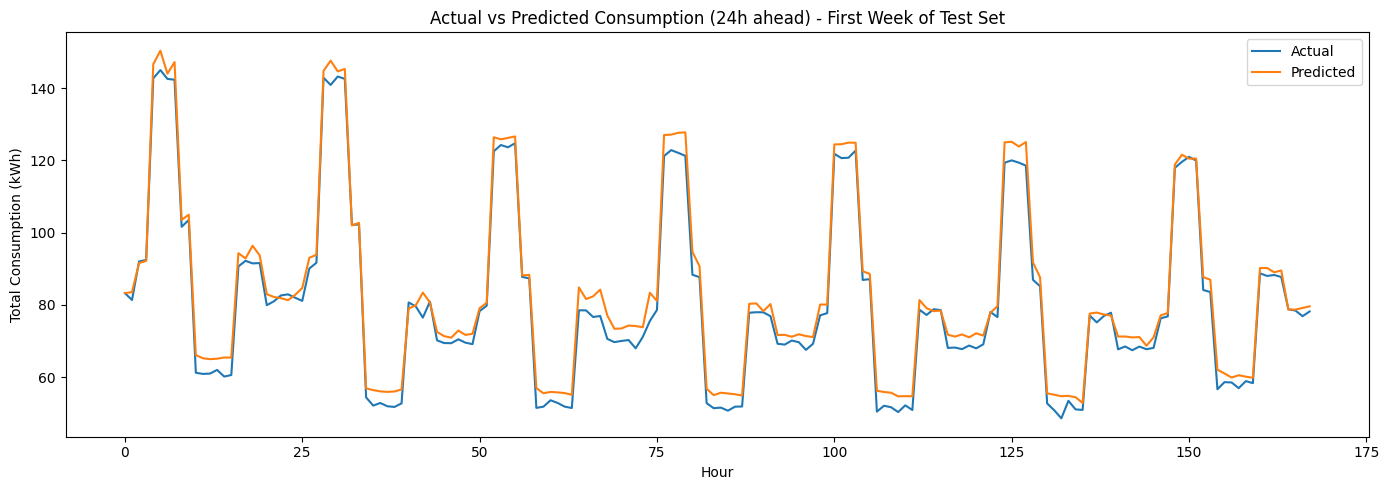

In [46]:
plt.figure(figsize=(14, 5))
plt.plot(y_test.values[:168], label='Actual')
plt.plot(y_pred[:168], label='Predicted')
plt.title('Actual vs Predicted Consumption (24h ahead) - First Week of Test Set')
plt.xlabel('Hour')
plt.ylabel('Total Consumption (kWh)')
plt.legend()
plt.tight_layout()
plt.savefig('results/Actual_vs_Predicted.png', dpi=150)
plt.show()

In [47]:
anomaly_features = ['total_consumption', 'temperature_c', 'humidity_percent', 'hour', 'day_of_week']
anomaly_df = city_df.copy()
anomaly_df['hour'] = anomaly_df['timestamp'].dt.hour
anomaly_df['day_of_week'] = anomaly_df['timestamp'].dt.dayofweek

X_anomaly = anomaly_df[anomaly_features]

anomaly_model = IsolationForest(
    n_estimators=200,
    contamination=0.02,
    random_state=RANDOM_SEED
)
anomaly_model.fit(X_anomaly)

anomaly_df['anomaly_score'] = anomaly_model.decision_function(X_anomaly)
anomaly_df['is_anomaly'] = anomaly_model.predict(X_anomaly)
anomaly_df['is_anomaly'] = anomaly_df['is_anomaly'].map({1: 0, -1: 1})

print("Detected anomalies (normal data):", anomaly_df['is_anomaly'].sum())

Detected anomalies (normal data): 176


In [48]:
injected_df = anomaly_df.copy()
np.random.seed(RANDOM_SEED)

num_injections = 20
injection_indices = np.random.choice(injected_df.index, size=num_injections, replace=False)

for idx in injection_indices[:10]:
    injected_df.loc[idx, 'total_consumption'] *= np.random.uniform(3, 5)

for idx in injection_indices[10:]:
    injected_df.loc[idx, 'total_consumption'] = 0.0

injected_df['is_injected'] = 0
injected_df.loc[injection_indices, 'is_injected'] = 1

X_injected = injected_df[anomaly_features]
injected_df['anomaly_score'] = anomaly_model.decision_function(X_injected)
injected_df['is_anomaly'] = anomaly_model.predict(X_injected)
injected_df['is_anomaly'] = injected_df['is_anomaly'].map({1: 0, -1: 1})

detected = injected_df.loc[injection_indices, 'is_anomaly'].sum()
print(f"Injected anomalies: {num_injections}")
print(f"Detected by model: {detected}")
print(f"Detection rate: {detected / num_injections * 100:.1f}%")

Injected anomalies: 20
Detected by model: 8
Detection rate: 40.0%


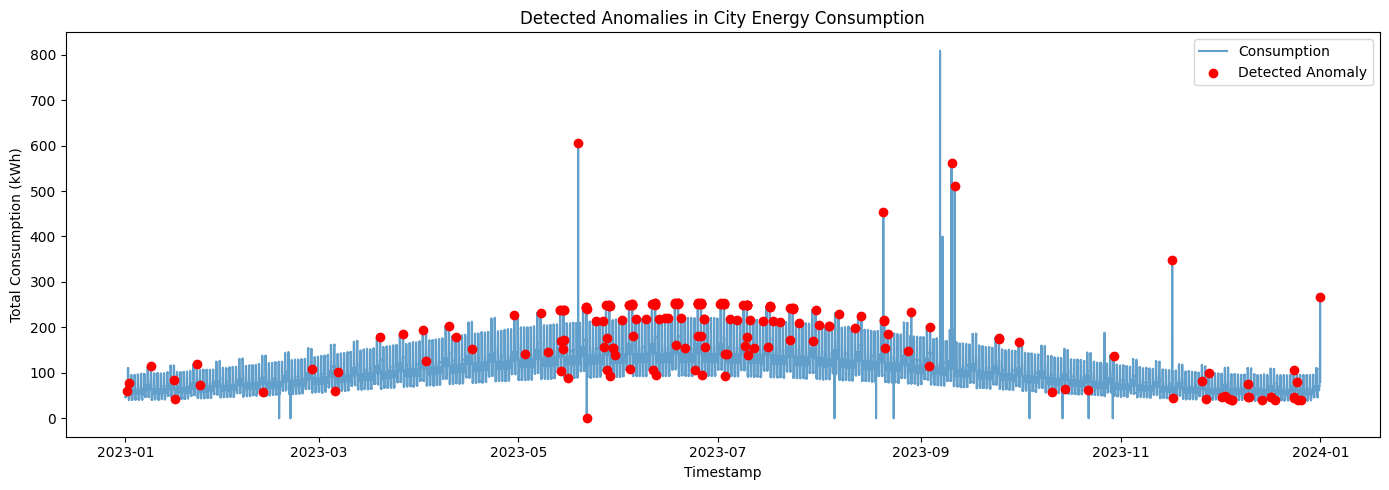

In [49]:
plt.figure(figsize=(14, 5))
plt.plot(injected_df['timestamp'], injected_df['total_consumption'], label='Consumption', alpha=0.7)

anomalies = injected_df[injected_df['is_anomaly'] == 1]
plt.scatter(anomalies['timestamp'], anomalies['total_consumption'],
            color='red', label='Detected Anomaly', zorder=5)

plt.title('Detected Anomalies in City Energy Consumption')
plt.xlabel('Timestamp')
plt.ylabel('Total Consumption (kWh)')
plt.legend()
plt.tight_layout()
plt.savefig('results/Detected_Anomalies.png', dpi=150)
plt.show()

C:\Users\AliZibaie\AppData\Local\Temp\ipykernel_6968\4016977516.py:4: FutureWarning: The NumPy global RNG was seeded by calling `np.random.seed`. In a future version this function will no longer use the global RNG. Pass `rng` explicitly to opt-in to the new behaviour and silence this warning.
  shap.summary_plot(shap_values, X_test, feature_names=feature_cols, show=False)


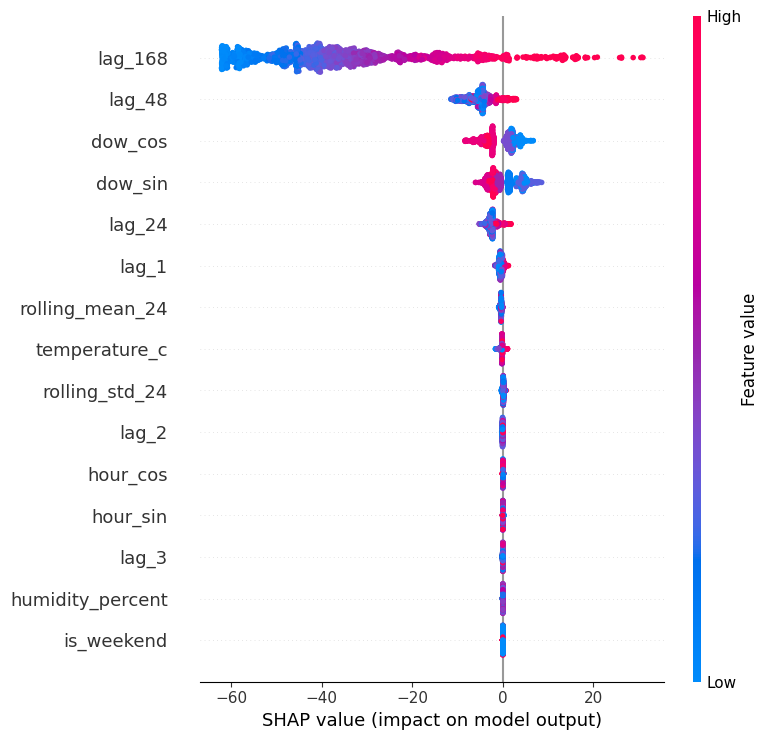

In [50]:
explainer = shap.TreeExplainer(forecast_model)
shap_values = explainer.shap_values(X_test)

shap.summary_plot(shap_values, X_test, feature_names=feature_cols, show=False)
plt.savefig("results/shap_summary.png", dpi=300, bbox_inches="tight")
plt.show()

C:\Users\AliZibaie\AppData\Local\Temp\ipykernel_6968\510784569.py:1: FutureWarning: The NumPy global RNG was seeded by calling `np.random.seed`. In a future version this function will no longer use the global RNG. Pass `rng` explicitly to opt-in to the new behaviour and silence this warning.
  shap.summary_plot(shap_values, X_test, feature_names=feature_cols, plot_type='bar', show=False)


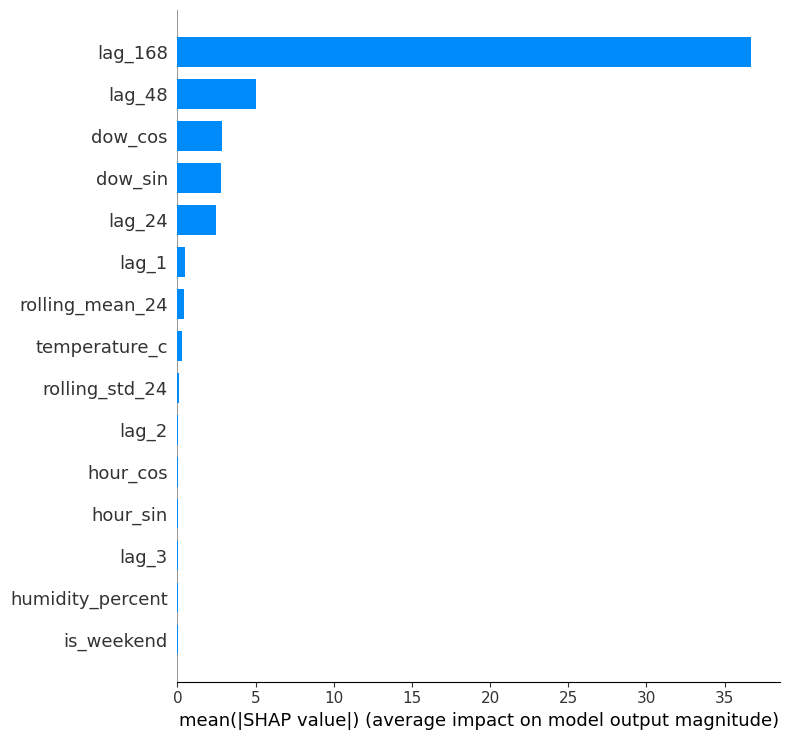

In [51]:
shap.summary_plot(shap_values, X_test, feature_names=feature_cols, plot_type='bar', show=False)
plt.savefig("results/shap_bar_summary.png", dpi=300, bbox_inches="tight")
plt.show()

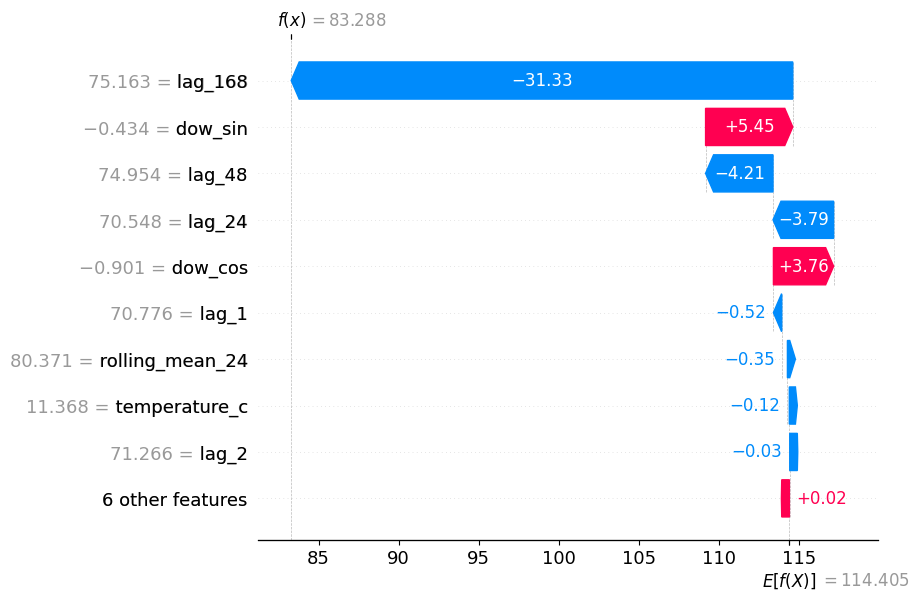

In [52]:
sample_idx = 0
shap.plots.waterfall(
    shap.Explanation(
        values=shap_values[sample_idx],
        base_values=explainer.expected_value,
        data=X_test.iloc[sample_idx],
        feature_names=feature_cols
    ),
    show=False
)

plt.savefig("results/waterfall_plot.png", dpi=300, bbox_inches="tight")
plt.show()
plt.close()

In [53]:


os.makedirs("../models", exist_ok=True)

# Save forecast model
joblib.dump(forecast_model, "../models/forecast_model.joblib")

# Save anomaly model
joblib.dump(anomaly_model, "../models/anomaly_detector.joblib")

print("Models exported successfully.")

Models exported successfully.


In [54]:
conn.close()